# SAS vs ESN — Multi-DGP Benchmark

Compares **SAS variants** (DiagonalPoly, LRUBlock, BlockLinear) against a classic
**ESN** (JaxESN — reservoirpy weight init, JAX `lax.scan` forward pass) on three
reservoirpy data-generating processes:

| DGP | Type | Input dim | Forecast target |
|---|---|---|---|
| **Lorenz** | chaotic ODE, 3D | d = 3  (x, y, z) | x(t+1) |
| **MSO-8** | quasi-periodic, 1D | d = 1 | y(t+1) |
| **Kuramoto-Sivashinsky** | turbulent PDE, 128D | d = 5 (5 spatial locs) | u₀(t+1) |

**100 evaluations per model per DGP** (10 data windows × 10 model seeds).

Both ESN and SAS use JAX `lax.scan` + JIT for the forward pass — timing is
apples-to-apples.  The ESN weight matrices (Win, W) are initialised via reservoirpy
so results remain reproducible from a given seed.

DGP and model configurations are in `config.yaml`.
Run `python run_benchmark.py` to generate JSON result files,
then use the cells below to visualise.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import json
import time
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import jax
import reservoirpy as rpy
import saspy

from esn import JaxESN
from run_benchmark import (
    load_dgp, make_sas_forecaster, make_esn,
    eval_sas, eval_esn, run_dgp_benchmark,
    warmup_esn, warmup_sas,
)

try:
    rpy.verbosity(0)
except AttributeError:
    pass

print(f"saspy      : {saspy.__version__}")
print(f"reservoirpy: {rpy.__version__}  (weight init only)")
print(f"JAX backend: {jax.default_backend()}")
print(f"ESN engine : JaxESN — lax.scan + JIT (same weights as reservoirpy for each seed)")

saspy      : 0.2.0
reservoirpy: 0.4.1  (weight init only)
JAX backend: cpu
ESN engine : JaxESN — lax.scan + JIT (same weights as reservoirpy for each seed)


In [2]:
# ── Load config ────────────────────────────────────────────────────────────
CONFIG_PATH = pathlib.Path("config.yaml")

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

BENCHMARK_CFG = cfg["benchmark"]
DGPS_CFG      = cfg["dgps"]
MODELS_CFG    = cfg["models"]

MODEL_COLORS = {
    "esn":          "tab:orange",
    "sas_diagonal": "tab:green",
    "sas_lru":      "tab:blue",
    "sas_block":    "tab:purple",
}

print("DGPs  :", list(DGPS_CFG.keys()))
print("Models:", list(MODELS_CFG.keys()))

DGPs  : ['lorenz', 'mso8', 'kuramoto_sivashinsky']
Models: ['esn', 'sas_diagonal', 'sas_diag_rff', 'sas_diag_q1', 'sas_lru_polyq1', 'sas_lru_polyq2']


## Dataset preview

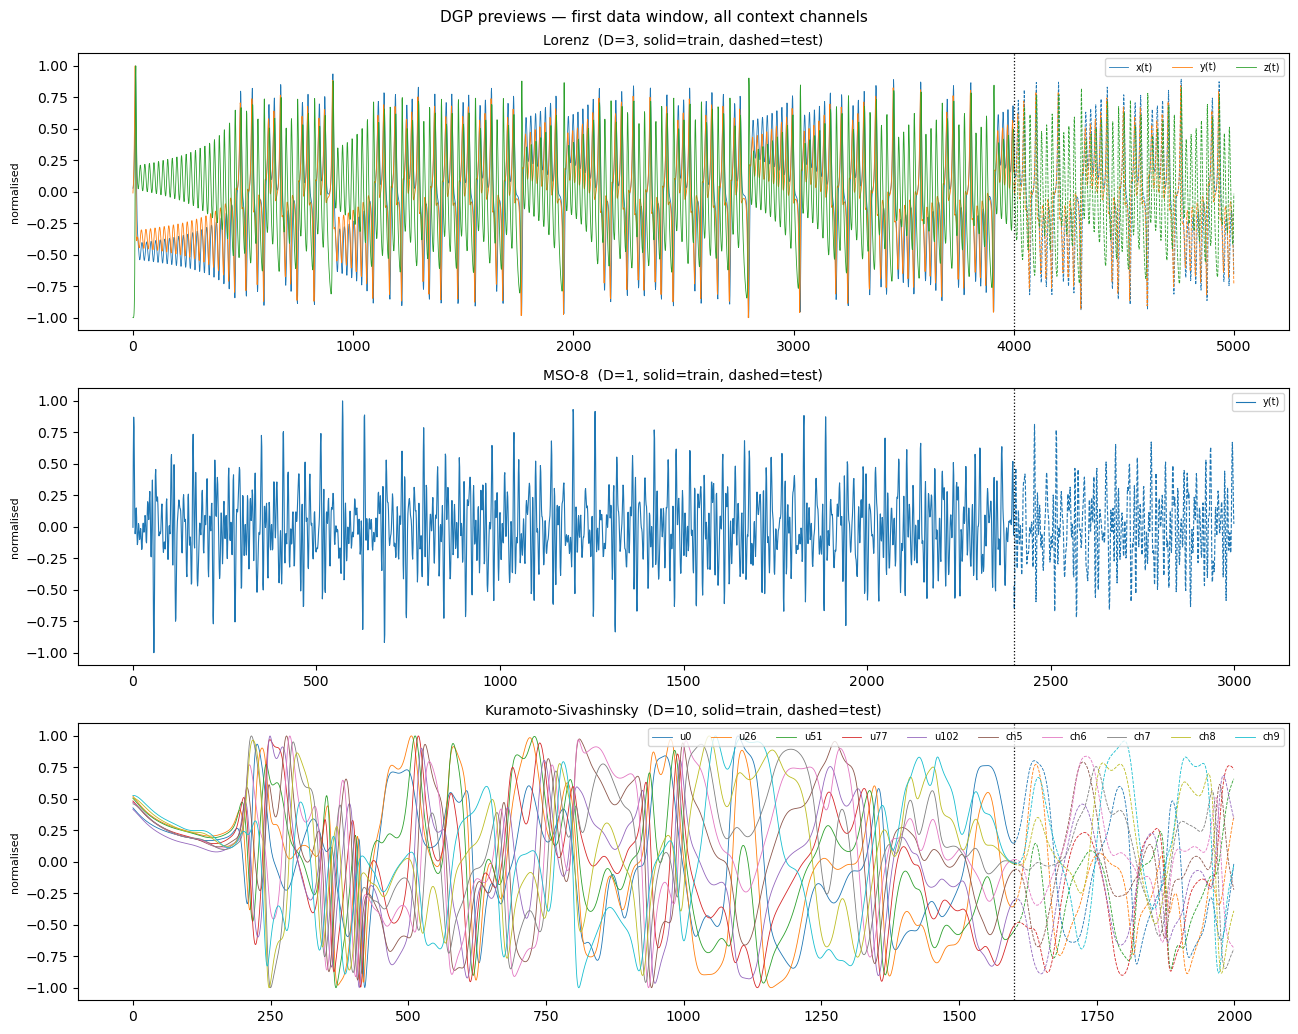

In [3]:
# Preview one trajectory window per DGP (target channel + context channels)
fig, axes = plt.subplots(len(DGPS_CFG), 1,
                         figsize=(13, 3.5 * len(DGPS_CFG)), sharex=False)
if len(DGPS_CFG) == 1:
    axes = [axes]

CHAN_LABELS = {
    "lorenz":                  ["x(t)", "y(t)", "z(t)"],
    "mso8":                    ["y(t)"],
    "kuramoto_sivashinsky":    ["u0", "u26", "u51", "u77", "u102"],
}

for ax, (dgp_name, dgp_cfg) in zip(axes, DGPS_CFG.items()):
    seed    = dgp_cfg["data_seeds"][0]
    data    = load_dgp(dgp_cfg, seed)          # (T, D)
    n_train = dgp_cfg["n_train"]
    T, D    = data.shape
    ts      = np.arange(T)
    labels  = CHAN_LABELS.get(dgp_name, [f"ch{i}" for i in range(D)])

    # Plot each channel; channel 0 (target) is opaque, rest are faded
    cmap = plt.cm.tab10
    for d in range(D):
        alpha = 1.0
        lw    = 0.8 if D == 1 else 0.6
        col   = cmap(d)
        ax.plot(ts[:n_train], data[:n_train, d],
                color=col, lw=lw, alpha=alpha,
                label=labels[d] if d < len(labels) else f"ch{d}")
        ax.plot(ts[n_train:], data[n_train:, d],
                color=col, lw=lw, alpha=alpha, ls="--")

    ax.axvline(n_train, color="k", ls=":", lw=0.9)
    ax.set_title(f"{dgp_cfg['label']}  (D={D}, solid=train, dashed=test)",
                 fontsize=10)
    ax.set_ylabel("normalised", fontsize=8)
    ax.legend(fontsize=7, ncol=D, loc="upper right")

plt.suptitle("DGP previews — first data window, all context channels", fontsize=11)
plt.tight_layout()
plt.show()

## Run benchmark

You can also run `python run_benchmark.py` from the terminal and then jump straight to
the **Load & visualise results** section below.

In [4]:
# ── Select which DGPs / models to run ─────────────────────────────────────
# Comment out entries you want to skip.
ACTIVE_DGPS   = list(DGPS_CFG.keys())
ACTIVE_MODELS = list(MODELS_CFG.keys())

# ── Run ───────────────────────────────────────────────────────────────────
all_results = []
for dgp_name in ACTIVE_DGPS:
    res = run_dgp_benchmark(
        dgp_name=dgp_name,
        dgp_cfg=DGPS_CFG[dgp_name],
        models_cfg=MODELS_CFG,
        active_models=ACTIVE_MODELS,
        benchmark_cfg=BENCHMARK_CFG,
        verbose=True,
    )
    all_results.append(res)
    # Optionally save
    slim = {
        "dgp": res["dgp"],
        "label": res["label"],
        "cold_jit_times": res["cold_jit_times"],
        "records": {
            mkey: [{k: v for k, v in r.items() if k != "preds"} for r in recs]
            for mkey, recs in res["records"].items()
        },
    }
    out_path = pathlib.Path("results") / f"{dgp_name}.json"
    out_path.parent.mkdir(exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(slim, f, indent=2)

print("\nDone.")


 DGP: Lorenz
   data_seed           ESN  SAS-Diagonal  SAS-Diag+RFF   SAS-Diag-Q1  SAS-LRU-Poly  SAS-LRU-Poly
  ------------------------------------------------------------------------------------------------
  ESN cold JIT: 322 ms (excluded from timing)
  SAS-Diagonal cold JIT: 1883 ms (excluded from timing)


/Users/yannkerzreho/Documents/PR/saspy/saspy/forecaster.py:166: UserWarning: Ridge alpha=1.00e-06 hit grid boundary [1.00e-06, 1.00e+06]. Consider extending ALPHAS.
  alpha              = _ridge_cv(S, Y, self.n_cv_folds, self.alphas)


  SAS-Diag+RFF cold JIT: 801 ms (excluded from timing)
  SAS-Diag-Q1 cold JIT: 573 ms (excluded from timing)
  SAS-LRU-PolyQ1 cold JIT: 1449 ms (excluded from timing)
  SAS-LRU-PolyQ2 cold JIT: 1096 ms (excluded from timing)


/Users/yannkerzreho/Documents/PR/saspy/benchmarks/run_benchmark.py:238: UserWarning: Ridge alpha=1.00e-06 hit grid boundary [1.00e-06, 1.00e+06]. Consider extending ALPHAS.
  alpha = _ridge_cv_select(S, Y_z)


           0       0.00074       0.00034       0.00036       0.00424       0.00486       0.00071
           1       0.00561       0.00042       0.00043       0.00488       0.00549       0.00092
           2       0.00105       0.00037       0.00039       0.00452       0.00500       0.00070
           3       0.00136       0.00037       0.00040       0.00471       0.00518       0.00068
           4       0.00138       0.00041       0.00042       0.00437       0.00499       0.00077
           5       0.00134       0.00034       0.00037       0.00433       0.00479       0.00068
           6       0.00185       0.00040       0.00042       0.00476       0.00536       0.00080
           7       0.00187       0.00040       0.00043       0.00476       0.00519       0.00071
           8       0.00234       0.00038       0.00041       0.00468       0.00517       0.00073
           9       0.00185       0.00037       0.00039       0.00466       0.00521       0.00074

 DGP: MSO-8
   data_seed     

## Load & visualise results

If you ran the benchmark via `python run_benchmark.py`, load the saved JSON files:

In [5]:
# If you ran via the notebook, `all_results` is already populated.
# If you ran via run_benchmark.py, uncomment the block below:

# all_results = []
# for dgp_name in DGPS_CFG.keys():
#     path = pathlib.Path("results") / f"{dgp_name}.json"
#     if path.exists():
#         with open(path) as f:
#             all_results.append(json.load(f))

print(f"Loaded {len(all_results)} DGP result sets.")
for r in all_results:
    total = sum(len(v) for v in r["records"].values())
    print(f"  {r['label']}: {total} total evaluations across {len(r['records'])} models")

Loaded 3 DGP result sets.
  Lorenz: 600 total evaluations across 6 models
  MSO-8: 600 total evaluations across 6 models
  Kuramoto-Sivashinsky: 600 total evaluations across 6 models


## Summary table

In [6]:
def agg(records, key):
    v = np.array([r[key] for r in records])
    return float(v.mean()), float(v.std())

model_keys = list(MODELS_CFG.keys())
col_w = 16

print(f"{'DGP':<17}" + "".join(f"  {MODELS_CFG[m]['label'][:col_w]:>{col_w}}" for m in model_keys))
print("-" * (21 + col_w * len(model_keys) + 2 * len(model_keys)))
print("RMSE (mean ± std)")
for res in all_results:
    row = f"  {res['label']:<23}"
    for mkey in model_keys:
        if mkey not in res["records"]:
            row += f"  {'—':>{col_w}}"
            continue
        mu, sd = agg(res["records"][mkey], "rmse")
        row += f"  {mu:.5f}±{sd:.5f}"
    print(row)

print()
n_steps_map = {name: cfg["n_total"] - cfg["n_train"]
               for name, cfg in DGPS_CFG.items()}

print("Fit time (ms)  — state scan + ridge CV/fit")
for res in all_results:
    row = f"  {res['label']:<23}"
    for mkey in model_keys:
        if mkey not in res["records"]: row += f"  {'—':>{col_w}}"; continue
        mu, sd = agg(res["records"][mkey], "t_fit")
        row += f"  {mu*1e3:5.1f}±{sd*1e3:.1f} ms"
    print(row)

print()
print("Stream time (ms)  — 1 batched call, T_test steps each")
print("  ESN: JaxESN.run(X_tr[-1:]) + JaxESN.run(X_te[:-1])  [JAX lax.scan + JIT]")
print("  SAS: _stream_scan via lax.scan                        [JAX lax.scan + JIT]")
for res in all_results:
    T_te = n_steps_map.get(res["dgp"], "?")
    row = f"  {res['label']:<23}"
    for mkey in model_keys:
        if mkey not in res["records"]: row += f"  {'—':>{col_w}}"; continue
        mu, sd = agg(res["records"][mkey], "t_stream")
        row += f"  {mu*1e3:5.2f}±{sd*1e3:.2f} ms"
    print(row)

DGP                             ESN      SAS-Diagonal      SAS-Diag+RFF       SAS-Diag-Q1    SAS-LRU-PolyQ1    SAS-LRU-PolyQ2
---------------------------------------------------------------------------------------------------------------------------------
RMSE (mean ± std)
  Lorenz                   0.00194±0.00159  0.00038±0.00003  0.00040±0.00003  0.00459±0.00020  0.00512±0.00037  0.00074±0.00008
  MSO-8                    0.01983±0.01008  0.00181±0.00025  0.00387±0.00049  0.00107±0.00009  0.00006±0.00007  0.00271±0.00148
  Kuramoto-Sivashinsky     0.02889±0.02253  0.00164±0.00071  0.00174±0.00090  0.00043±0.00025  0.00546±0.00666  0.01137±0.00797

Fit time (ms)  — state scan + ridge CV/fit
  Lorenz                    79.5±53.3 ms   90.1±183.1 ms   52.8±59.2 ms   50.0±62.3 ms   70.6±90.8 ms   57.9±39.2 ms
  MSO-8                     61.2±45.7 ms   53.3±50.8 ms   46.1±45.2 ms   52.1±38.2 ms   70.2±50.8 ms   57.8±28.0 ms
  Kuramoto-Sivashinsky      89.4±80.2 ms   61.2±38.9 ms   64.1±87

## RMSE distribution per DGP

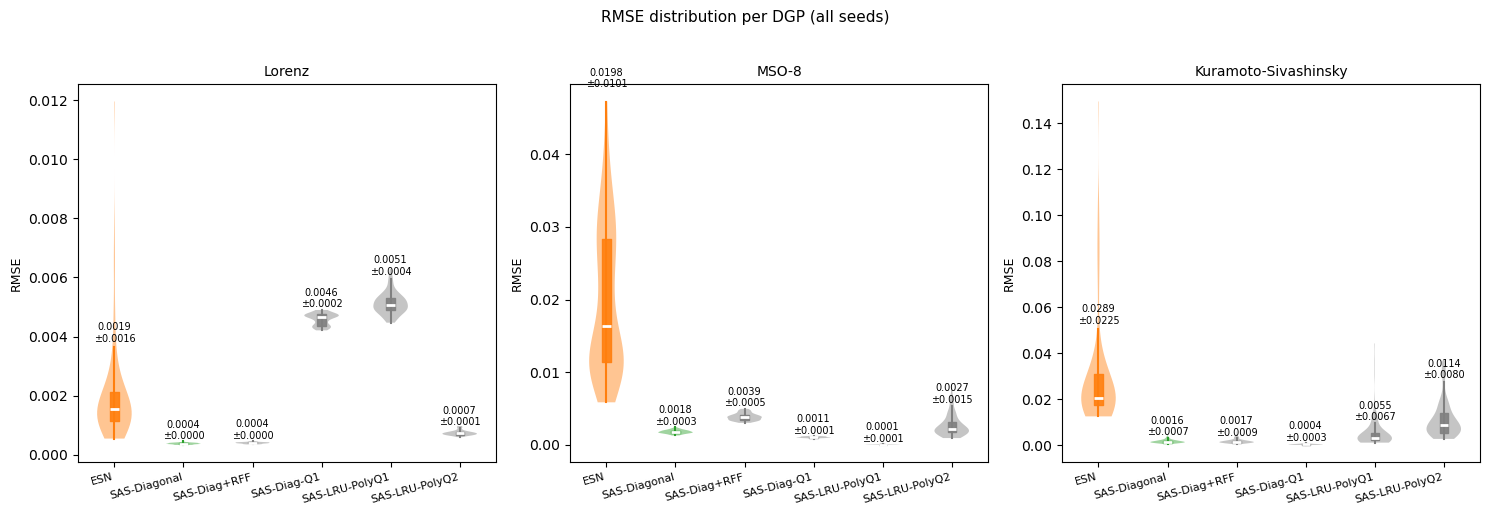

In [7]:
n_dgps = len(all_results)
fig, axes = plt.subplots(1, n_dgps, figsize=(5 * n_dgps, 5), sharey=False)
if n_dgps == 1:
    axes = [axes]

for ax, res in zip(axes, all_results):
    model_keys_avail = [m for m in MODELS_CFG if m in res["records"]]
    data_list = [np.array([r["rmse"] for r in res["records"][m]]) for m in model_keys_avail]
    labels    = [MODELS_CFG[m]["label"] for m in model_keys_avail]
    colors    = [MODEL_COLORS.get(m, "gray") for m in model_keys_avail]

    parts = ax.violinplot(data_list, positions=range(len(data_list)),
                          showmedians=False, showextrema=False)
    for pc, col in zip(parts["bodies"], colors):
        pc.set_facecolor(col)
        pc.set_alpha(0.45)

    for i, (vals, col) in enumerate(zip(data_list, colors)):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lo  = max(vals.min(), q1 - 1.5 * iqr)
        hi  = min(vals.max(), q3 + 1.5 * iqr)
        ax.plot([i, i], [lo, hi], color=col, lw=1.5, zorder=3)
        ax.fill_between([i - 0.06, i + 0.06], q1, q3, color=col, alpha=0.9, zorder=4)
        ax.hlines(med, i - 0.06, i + 0.06, colors="white", linewidth=2, zorder=5)
        ax.text(i, hi + (hi - lo) * 0.04,
                f"{vals.mean():.4f}\n±{vals.std():.4f}",
                ha="center", va="bottom", fontsize=7)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("RMSE", fontsize=9)
    ax.set_title(res["label"], fontsize=10)

plt.suptitle("RMSE distribution per DGP (all seeds)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Timing comparison

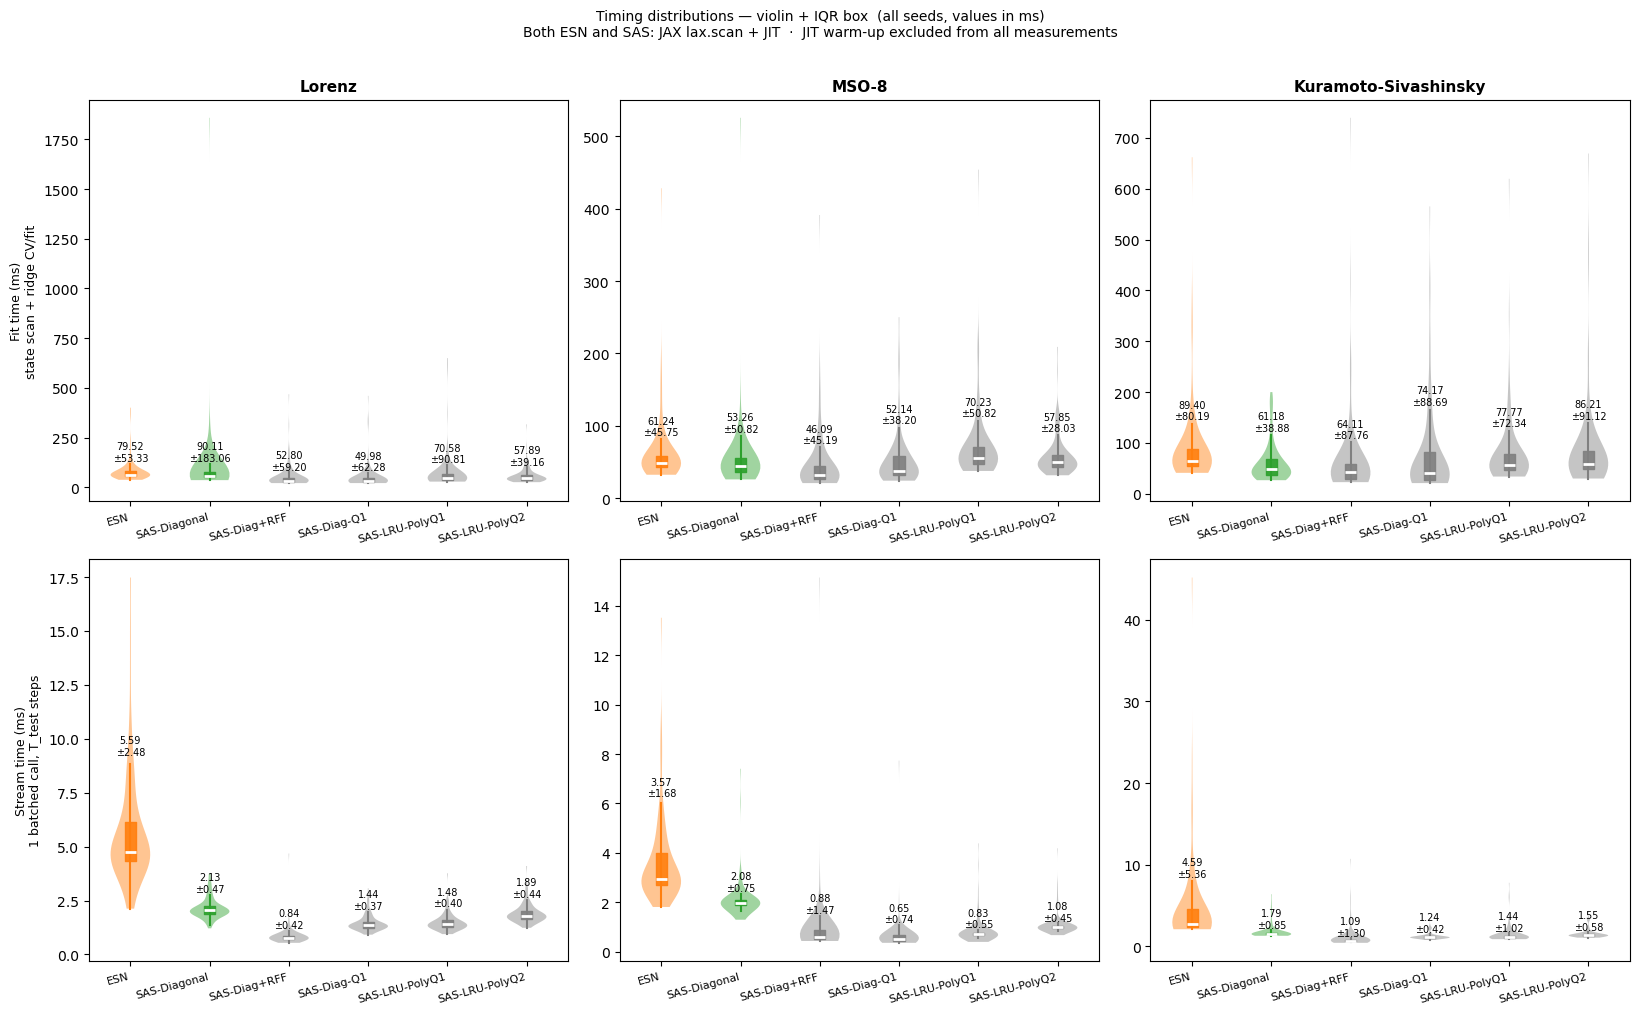

In [8]:
# ── 2 × n_dgps timing grid ─────────────────────────────────────────────────
# row 0 → fit time  (state scan + ridge CV/fit)
# row 1 → stream time  (1 batched call, T_test steps)
# columns → one per DGP
# style  → violin + IQR box + whiskers + mean±std annotation  (same as RMSE cell)
# ───────────────────────────────────────────────────────────────────────────

metrics = [
    ("t_fit",    "Fit time (ms)\nstate scan + ridge CV/fit"),
    ("t_stream", "Stream time (ms)\n1 batched call, T_test steps"),
]

n_dgps = len(all_results)
fig, axes = plt.subplots(2, n_dgps,
                         figsize=(5.5 * n_dgps, 10),
                         sharey=False)

def _violin_box(ax, data_list, labels, colors):
    """Draw violin + IQR box overlay on ax."""
    parts = ax.violinplot(data_list,
                          positions=range(len(data_list)),
                          showmedians=False, showextrema=False)
    for pc, clr in zip(parts["bodies"], colors):
        pc.set_facecolor(clr)
        pc.set_alpha(0.45)

    for i, (vals, clr) in enumerate(zip(data_list, colors)):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr  = q3 - q1
        lo   = max(vals.min(), q1 - 1.5 * iqr)
        hi   = min(vals.max(), q3 + 1.5 * iqr)
        span = max(hi - lo, 1e-9)
        # whisker
        ax.plot([i, i], [lo, hi], color=clr, lw=1.5, zorder=3)
        # IQR box
        ax.fill_between([i - 0.07, i + 0.07], q1, q3,
                        color=clr, alpha=0.9, zorder=4)
        # median line
        ax.hlines(med, i - 0.07, i + 0.07,
                  colors="white", linewidth=2, zorder=5)
        # mean ± std label above whisker
        ax.text(i, hi + span * 0.05,
                f"{vals.mean():.2f}\n±{vals.std():.2f}",
                ha="center", va="bottom", fontsize=7)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=8)

for row, (metric_key, row_ylabel) in enumerate(metrics):
    for col, res in enumerate(all_results):
        ax = axes[row, col]

        model_keys_avail = [m for m in MODELS_CFG if m in res["records"]]
        data_list = [
            np.array([r[metric_key] for r in res["records"][m]]) * 1e3   # → ms
            for m in model_keys_avail
        ]
        labels = [MODELS_CFG[m]["label"] for m in model_keys_avail]
        colors = [MODEL_COLORS.get(m, "gray") for m in model_keys_avail]

        _violin_box(ax, data_list, labels, colors)

        if col == 0:
            ax.set_ylabel(row_ylabel, fontsize=9)
        if row == 0:
            ax.set_title(res["label"], fontsize=11, fontweight="bold")

plt.suptitle(
    "Timing distributions — violin + IQR box  (all seeds, values in ms)\n"
    "Both ESN and SAS: JAX lax.scan + JIT  ·  JIT warm-up excluded from all measurements",
    fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## RMSE heatmap — DGP × model

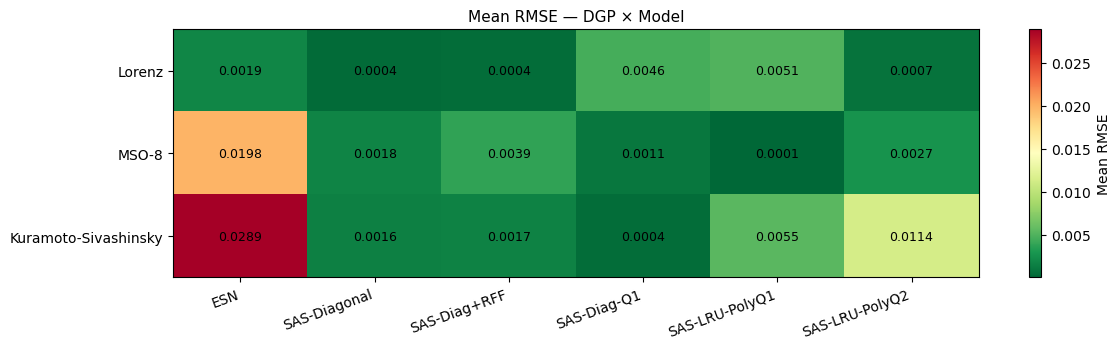

In [9]:
model_keys_avail = list(MODELS_CFG.keys())
dgp_labels   = [r["label"] for r in all_results]
model_labels = [MODELS_CFG[m]["label"] for m in model_keys_avail]

# Build mean RMSE matrix (n_dgps x n_models)
matrix = np.full((len(all_results), len(model_keys_avail)), np.nan)
for i, res in enumerate(all_results):
    for j, mkey in enumerate(model_keys_avail):
        if mkey in res["records"] and res["records"][mkey]:
            matrix[i, j] = np.mean([r["rmse"] for r in res["records"][mkey]])

fig, ax = plt.subplots(figsize=(max(6, len(model_keys_avail) * 2), max(3, len(all_results) * 1.2)))
im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Mean RMSE")

ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, rotation=20, ha="right")
ax.set_yticks(range(len(dgp_labels)))
ax.set_yticklabels(dgp_labels)

for i in range(len(all_results)):
    for j in range(len(model_keys_avail)):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f"{matrix[i, j]:.4f}", ha="center", va="center",
                    fontsize=9, color="black")

ax.set_title("Mean RMSE — DGP × Model", fontsize=11)
plt.tight_layout()
plt.show()

## Valid Prediction Time (VPT)

**VPT** measures how many time steps an *autonomous* (closed-loop, no teacher forcing) rollout
stays close to the true trajectory before diverging:

$$\text{VPT}_\varepsilon = \min\bigl\{t \geq 0 : \text{NRMSE}(t) \geq \varepsilon \bigr\}$$

$$\text{NRMSE}(t) = \frac{\sqrt{\frac{1}{D}\sum_{d=1}^{D}\bigl(\hat{y}_{t,d} - y_{t,d}\bigr)^2}}{\sigma_{\text{target}}}, \qquad \sigma_{\text{target}} = \sqrt{\frac{1}{D}\sum_d \text{Var}(y_{\cdot,d})}$$

VPT is the key metric for chaotic systems because it directly measures the **effective forecasting horizon** —
the time before exponential error growth (Lyapunov divergence) overwhelms the prediction.
It is reported in **Lyapunov times** $T_L = 1/\lambda_{\max}$ for Lorenz and KS,
and in raw steps for MSO-8 (quasi-periodic, $\lambda=0$).

Threshold: $\varepsilon = 0.4$ (standard in reservoir-computing literature).

In [ ]:
from run_benchmark import compute_vpt, _autonomous_nrmse

VPT_THRESHOLD = BENCHMARK_CFG.get("vpt_threshold", 0.4)

# ── VPT summary table ─────────────────────────────────────────────────────────
model_keys = list(MODELS_CFG.keys())

for res in all_results:
    lyt     = res.get("lyapunov_time_steps")
    has_vpt = any(
        "vpt" in r
        for mkey in model_keys
        for r in res["records"].get(mkey, [])
    )
    if not has_vpt:
        print(f"  {res['label']}: no VPT data — re-run benchmark to generate.")
        continue

    unit_label = f"Lyapunov times  (T_L = {lyt} steps)" if lyt else "steps"
    print(f"{'─'*64}")
    print(f"  {res['label']}   [VPT in {unit_label}]")
    print(f"{'─'*64}")
    print(f"  {'Model':<22}  {'mean VPT':>10}  {'± std':>8}  {'min':>8}  {'max':>8}  n")
    print(f"  {'─'*22}  {'─'*10}  {'─'*8}  {'─'*8}  {'─'*8}  ─")

    for mkey in model_keys:
        if mkey not in res["records"]:
            continue
        vpts = np.array([r["vpt"] for r in res["records"][mkey] if "vpt" in r], dtype=float)
        if len(vpts) == 0:
            continue
        label = MODELS_CFG[mkey]["label"]
        scale = lyt if lyt else 1
        print(
            f"  {label:<22}  {vpts.mean()/scale:>10.2f}  "
            f"{vpts.std()/scale:>8.2f}  "
            f"{vpts.min()/scale:>8.2f}  "
            f"{vpts.max()/scale:>8.2f}  {len(vpts)}"
        )
    print()

In [ ]:
# ── VPT bar chart — mean ± std per model per DGP ─────────────────────────────
results_with_vpt = [
    res for res in all_results
    if any("vpt" in r for mkey in MODELS_CFG for r in res["records"].get(mkey, []))
]

if not results_with_vpt:
    print("No VPT data yet — run the benchmark first.")
else:
    n_dgps     = len(results_with_vpt)
    model_keys = list(MODELS_CFG.keys())

    fig, axes = plt.subplots(1, n_dgps, figsize=(5.5 * n_dgps, 5), sharey=False)
    if n_dgps == 1:
        axes = [axes]

    for ax, res in zip(axes, results_with_vpt):
        lyt          = res.get("lyapunov_time_steps")
        keys_avail   = [m for m in model_keys if m in res["records"]]
        labels       = [MODELS_CFG[m]["label"] for m in keys_avail]
        colors       = [MODEL_COLORS.get(m, "tab:gray") for m in keys_avail]
        scale        = lyt if lyt else 1

        means, stds, all_vpts = [], [], []
        for mkey in keys_avail:
            vpts = np.array([r["vpt"] for r in res["records"][mkey] if "vpt" in r], dtype=float)
            means.append(vpts.mean() / scale)
            stds.append(vpts.std() / scale)
            all_vpts.append(vpts / scale)

        x = np.arange(len(means))
        # individual points (scatter)
        for xi, vals in enumerate(all_vpts):
            ax.scatter(np.full(len(vals), xi) + np.random.uniform(-0.18, 0.18, len(vals)),
                       vals, color=colors[xi], alpha=0.25, s=8, zorder=2)
        # bars
        ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.75,
               edgecolor="k", linewidth=0.6, zorder=3)
        # value labels
        for xi, (m, s) in enumerate(zip(means, stds)):
            ax.text(xi, m + s + max(means) * 0.02, f"{m:.1f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
        ax.set_ylabel("VPT / T_L (Lyapunov times)" if lyt else "VPT (steps)", fontsize=9)
        ax.set_title(res["label"], fontsize=10)
        ax.set_ylim(0, None)

    plt.suptitle(
        f"Valid Prediction Time (ε={VPT_THRESHOLD}) — autonomous closed-loop rollout\n"
        "Bar: mean ± std  ·  dots: individual evaluations  ·  Higher is better.",
        fontsize=10, y=1.02,
    )
    plt.tight_layout()
    plt.show()

### NRMSE curves — autonomous rollout (single seed)

Each curve shows NRMSE(t) for a single autonomous rollout from end of training.
The dashed line marks the VPT threshold ε = 0.4.
The x-axis is in Lyapunov times — the natural unit for chaotic systems.
Good models stay below the threshold longer (flat NRMSE during valid prediction),
then diverge sharply as Lyapunov instability accumulates.

In [ ]:
# ── NRMSE curves — autonomous rollout, one seed per model ────────────────────
# Runs a single closed-loop evaluation per model/DGP to obtain NRMSE(t).
# Only shows DGPs with a defined Lyapunov time (chaotic: Lorenz + KS).

import jax
import jax.numpy as jnp
from run_benchmark import (
    load_dgp, make_sas_forecaster, make_esn,
    _fit_multiout_readout, _autonomous_nrmse, compute_vpt,
)

DEMO_DATA_SEED  = 0
DEMO_MODEL_SEED = 0

dgp_names_plot = [n for n in DGPS_CFG if DGPS_CFG[n].get("lyapunov_time_steps")]
if not dgp_names_plot:   # fallback: show all
    dgp_names_plot = list(DGPS_CFG.keys())

model_keys = list(MODELS_CFG.keys())
n_dgps = len(dgp_names_plot)

fig, axes = plt.subplots(n_dgps, 1, figsize=(12, 4.5 * n_dgps), sharex=False)
if n_dgps == 1:
    axes = [axes]

for ax, dgp_name in zip(axes, dgp_names_plot):
    dgp_cfg    = DGPS_CFG[dgp_name]
    n_train    = dgp_cfg["n_train"]
    washout    = BENCHMARK_CFG["washout"]
    horizon    = BENCHMARK_CFG["horizon"]
    chunk_size = BENCHMARK_CFG["chunk_size"]
    lyt        = dgp_cfg.get("lyapunov_time_steps", 1)
    d_input    = len(dgp_cfg["channels"]) if "channels" in dgp_cfg else 1
    multivar   = d_input > 1

    data = load_dgp(dgp_cfg, DEMO_DATA_SEED)
    X_tr, X_te = data[:n_train], data[n_train:]
    T_te   = len(X_te)
    t_axis = np.arange(T_te) / lyt     # → Lyapunov times

    for mkey in model_keys:
        mcfg  = MODELS_CFG[mkey]
        color = MODEL_COLORS.get(mkey, "tab:gray")
        label = mcfg["label"]

        if mcfg["type"] == "esn":
            reservoir, wo = make_esn(mcfg, washout, DEMO_MODEL_SEED)
            D = X_tr.shape[1]
            states_tr = reservoir.run(X_tr[:-1].astype(np.float32))
            W_mat, mu, sigma, _ = _fit_multiout_readout(states_tr, X_tr[1:], wo, horizon=0)
            reservoir.run(X_tr[-1:].astype(np.float32))          # advance to end of train
            s_after = np.asarray(reservoir._state, dtype=np.float32)

            reservoir._state = jnp.array(s_after)
            preds_cl = np.empty((T_te, D), dtype=np.float64)
            W_np = np.asarray(W_mat)
            for t in range(T_te):
                s = np.asarray(reservoir._state, dtype=np.float64)
                y = s @ W_np * sigma + mu
                preds_cl[t] = y
                reservoir.run(np.clip(y, -10, 10)[None, :].astype(np.float32))

        else:  # sas
            fc = make_sas_forecaster(mcfg, washout, chunk_size, DEMO_MODEL_SEED, d=d_input)
            D  = d_input
            fc.fit(X_tr[:, 0], horizons=[horizon], context=X_tr if multivar else None)
            jax.block_until_ready(fc._s_last)
            W_mat, mu, sigma, _ = _fit_multiout_readout(fc._states_train, X_tr, washout, horizon)
            s_start = fc._s_last.copy()

            fc._s_last = s_start.copy()
            preds_cl = np.empty((T_te, D), dtype=np.float64)
            for t in range(T_te):
                preds_cl[t] = fc._s_last.astype(np.float64) @ W_mat * sigma + mu
                y_fb = np.clip(preds_cl[t], -10, 10)
                fc.update(y_fb if multivar else float(y_fb[0]))

        nrmse = _autonomous_nrmse(preds_cl, X_te)
        vpt   = compute_vpt(nrmse, VPT_THRESHOLD)
        # Clip for display (diverged predictions can be huge on log scale)
        nrmse_plot = np.clip(nrmse, 1e-5, 20)
        ax.semilogy(t_axis, nrmse_plot, color=color, lw=1.1, alpha=0.85,
                    label=f"{label}  VPT={vpt/lyt:.1f} T_L")

    # VPT threshold line
    ax.axhline(VPT_THRESHOLD, color="black", ls="--", lw=1.2, label=f"ε={VPT_THRESHOLD}")
    ax.set_xlabel("Time  (Lyapunov times)", fontsize=9)
    ax.set_ylabel("NRMSE  (log scale)", fontsize=9)
    ax.set_title(f"{dgp_cfg['label']}  —  autonomous NRMSE(t)  (data seed 0, model seed 0)",
                 fontsize=10)
    ax.legend(fontsize=7.5, ncol=2, loc="upper left")
    ax.set_ylim(1e-4, 15)

plt.suptitle(
    "NRMSE vs time — autonomous closed-loop rollout (no ground-truth input)\n"
    "Divergence of NRMSE past ε=0.4 marks the Valid Prediction Time.",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()